## Importing libraries and Loading dataset

In [ ]:
from PIL import Image
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import drive
drive.mount('/content/drive')
import zipfile

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/09_Face_detection/yalefaces.zip'
zip_object = zipfile.ZipFile(file = path, mode = 'r')

In [ ]:
zip_object.extractall('./')
zip_object.close()

In [ ]:
ls

drive/  __MACOSX/  sample_data/  yalefaces/


## Preprocess the image:

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/09_Face_detection/yalefaces/yalefaces/train'))

['subject01.glasses.gif', 'subject01.noglasses.gif', 'subject01.leftlight.gif', 'subject01.normal.gif', 'subject01.sad.gif', 'subject01.rightlight.gif', 'subject01.surprised.gif', 'subject01.sleepy.gif', 'subject01.wink.gif', 'subject02.glasses.gif', 'subject02.happy.gif', 'subject02.noglasses.gif', 'subject02.normal.gif', 'subject02.rightlight.gif', 'subject02.sleepy.gif', 'subject02.sad.gif', 'subject02.surprised.gif', 'subject02.wink.gif', 'subject03.centerlight.gif', 'subject03.happy.gif', 'subject03.noglasses.gif', 'subject03.normal.gif', 'subject03.rightlight.gif', 'subject03.sad.gif', 'subject03.sleepy.gif', 'subject03.wink.gif', 'subject03.surprised.gif', 'subject04.centerlight.gif', 'subject04.glasses.gif', 'subject04.happy.gif', 'subject04.noglasses.gif', 'subject04.rightlight.gif', 'subject04.normal.gif', 'subject04.sleepy.gif', 'subject05.centerlight.gif', 'subject04.wink.gif', 'subject05.glasses.gif', 'subject05.happy.gif', 'subject05.leftlight.gif', 'subject05.noglasses.g

In [ ]:
def get_image_data():
    paths = [os.path.join('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/09_Face_detection/yalefaces/yalefaces/train',f) for f in os.listdir('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/09_Face_detection/yalefaces/yalefaces/train')]
    #print(paths)

    faces = []
    ids = []

    for p in paths:
      #print(p)
      image = Image.open(p).convert('L') # Convertall the images into gray scale.
      #print(image)
      #print(type(image)) # class

      image_np = np.array(image, 'uint8') # universal integer 8.
      #print(image_np)

      id = int(os.path.split(p)[1].split('.')[0].replace('subject',''))
      #print(id)

      ids.append(id)
      faces.append(image_np)

    return np.array(ids), faces







In [ ]:
ids, faces = get_image_data()

In [ ]:
np.unique(ids)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [ ]:
ids

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,
        5,  4,  5,  5,  5,  5,  5,  5,  5,  6,  5,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,  8,
        8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15,  4])

In [ ]:
faces

[array([[130, 130, 130, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 252, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8),
 array([[130, 130, 130, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8),
 array([[130, 130, 130, ..., 216, 224, 244],
        [255, 255, 255, ..., 215, 220, 245],
        [255, 255, 255, ..., 231, 211, 231],
        ...,
        [255, 255, 255, ..., 192, 197, 203],
        [255, 255, 255, ..., 189, 207, 215],
        [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8),
 array([[130, 130, 130, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 25

In [ ]:
len(ids)

135

In [ ]:
len(faces)

135

array([[114, 121, 124, ..., 255, 238, 245],
       [255, 255, 255, ..., 255, 250, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [250, 255, 255, ..., 176, 163, 171],
       [250, 255, 255, ..., 185, 164, 165],
       [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8)
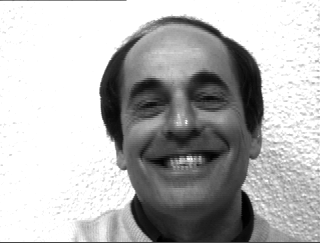

In [ ]:
faces[100]

In [ ]:
num_pixel = 243*320

In [ ]:
!pip install opencv-contrib-python==4.10.0.84


## Train the LBPH Classifier

In [ ]:
lbph_classifier = cv2.face.LBPHFaceRecognizer_create( radius = 4, neighbors = 14, grid_x = 9, grid_y = 9)

In [ ]:
#!pip install opencv-contrib-python==4.10.0.84


In [ ]:
lbph_classifier.train(faces, ids) #training
lbph_classifier.write('lbph_classifier.yml')

In [ ]:
ls

drive/  lbph_classifier.yml  __MACOSX/  sample_data/  yalefaces/


## Recognizing faces:

In [ ]:
lbph_face_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_face_classifier.read('/content/lbph_classifier.yml')

## Testing model from test image:

array([[130, 130, 130, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 249, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8)
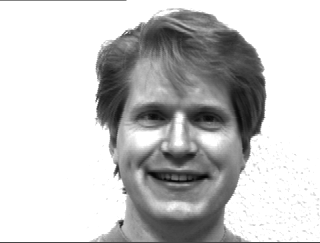

In [ ]:
# pass some image and check from test folder
sample_image = '/content/yalefaces/test/subject01.happy.gif'
image = Image.open(sample_image).convert('L')
np.array(image, 'uint8')

In [ ]:
image_np = np.array(image, 'uint8')

In [ ]:
# To predict
prediction = lbph_face_classifier.predict(image_np) # it gives label and confidence level.

In [ ]:
prediction

(1, 63.26476332390736)

In [ ]:
expected_output =  int(os.path.split(sample_image)[1].split('.')[0].replace('subject',''))
expected_output

1

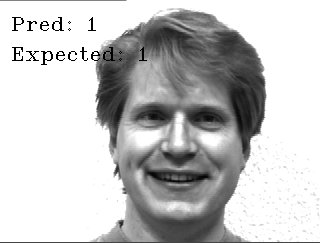

In [ ]:
cv2.putText(image_np, 'Pred: ' + str(prediction[0]), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,255))
cv2.putText(image_np, 'Expected: ' + str(expected_output), (10,60), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,255))
cv2_imshow(image_np)


## The above is for one image: ie; I gave one image from the test folder and predicted its output

## Evaluate the face classifier I trained above:

In [ ]:
os.listdir('/content/yalefaces/test')

['subject10.centerlight.gif',
 'subject14.sad.gif',
 'subject12.rightlight.gif',
 'subject12.normal.gif',
 'subject13.sleepy.gif',
 'subject11.glasses.gif',
 'subject05.sleepy.gif',
 'subject01.happy.gif',
 'subject03.glasses.gif',
 'subject15.rightlight.gif',
 'subject06.leftlight.gif',
 'subject02.leftlight.gif',
 'subject04.leftlight.gif',
 'subject09.rightlight.gif',
 'subject09.sad.gif',
 'subject14.normal.gif',
 'subject02.centerlight.gif',
 'subject10.sad.gif',
 'subject01.gif',
 'subject03.leftlight.gif',
 'subject05.surprised.gif',
 'subject08.rightlight.gif',
 'subject11.happy.gif',
 'subject13.sad.gif',
 'subject06.happy.gif',
 'subject15.sad.gif',
 'subject08.normal.gif',
 'subject07.leftlight.gif',
 'subject07.happy.gif',
 'subject04.surprised.gif']

In [ ]:
paths = [os.path.join('/content/yalefaces/test', f ) for f in os.listdir('/content/yalefaces/test')] # get the path

In [ ]:
 #paths

In [ ]:
predictions = []
expected_outputs = []

for p in paths:
  #print(p)
  image = Image.open(p).convert('L') # gray scale conversion
  image_np = np.array(image, 'uint8')

  prediction, _ = lbph_face_classifier.predict(image_np) # _--> ignore the confidence level/ probability.

  expected_output = os.path.split(p)[1].split('.')[0].replace('subject','')  # true label.

  predictions.append(prediction)
  expected_outputs.append(expected_output)



In [ ]:
# converting into array
predictions = np.array(predictions)
expected_outputs = np.array(expected_outputs, 'uint8')

In [ ]:
predictions

array([ 4, 14, 12, 12, 13, 11,  5,  1,  3,  7, 14, 12,  4,  7,  9, 14,  4,
       10,  4,  3,  5,  4, 11, 13,  6, 15,  8,  9,  7,  4])

In [ ]:
expected_outputs

array([10, 14, 12, 12, 13, 11,  5,  1,  3, 15,  6,  2,  4,  9,  9, 14,  2,
       10,  1,  3,  5,  8, 11, 13,  6, 15,  8,  7,  7,  4], dtype=uint8)

## How accurate we are: Confusion Matrix

A confusion matrix is a table used to evaluate the performance of a classification model (especially supervised learning). It compares the actual (true) labels with the predicted labels from your model.

|                     | **Predicted Positive** | **Predicted Negative** |
| ------------------: | :--------------------: | :--------------------: |
| **Actual Positive** |   True Positive (TP)   |   False Negative (FN)  |
| **Actual Negative** |   False Positive (FP)  |   True Negative (TN)   |
Example

Suppose:
Actual = [1, 0, 1, 1, 0, 1, 0, 0]
Predicted = [1, 0, 1, 0, 0, 1, 1, 0]

|              | **Predicted 1** | **Predicted 0** |
| -----------: | :-------------: | :-------------: |
| **Actual 1** |      3 (TP)     |      1 (FN)     |
| **Actual 0** |      1 (FP)     |      3 (TN)     |




### Example below:

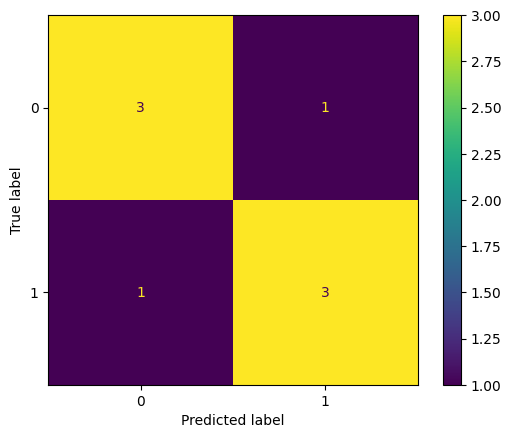

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = [1, 0, 1, 1, 0, 1, 0, 0]
y_pred = [1, 0, 1, 0, 0, 1, 1, 0]

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


#### Accuracy: How often/ how many cases model is correct?
Acc = (TP+TN)/Total
Accutracy paradox:
Happens when we have an imbalanced data ?
Accuracy

Definition:
Measures how often the model correctly predicts the classes.

Accuracy=TP+TNTP+TN+FP+FN
Accuracy=
TP+TN+FP+FN
TP+TN
	​


Interpretation:
It tells you the proportion of total predictions that were correct.

 Accuracy Paradox:

The accuracy paradox occurs when the dataset is imbalanced,
i.e., one class is much more frequent than the other.

In such cases, a model can have high accuracy but still perform poorly on the minority class.

Example:
If 95% of samples belong to Class A and only 5% to Class B,
a model that always predicts Class A will have 95% accuracy,
but it completely fails to detect Class B.




| Metric                   | Formula                                         | Meaning                                  |
| :----------------------- | :---------------------------------------------- | :--------------------------------------- |
| **Accuracy**             | (TP + TN) / (TP + TN + FP + FN)                 | Overall correctness                      |
| **Precision**            | TP / (TP + FP)                                  | How many predicted positives are correct |
| **Recall (Sensitivity)** | TP / (TP + FN)                                  | How many actual positives are captured   |
| **Specificity**          | TN / (TN + FP)                                  | How many actual negatives are captured   |
| **F1-Score**             | 2 × (Precision × Recall) / (Precision + Recall) | Harmonic mean of precision and recall    |


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
accuracy_score(expected_outputs, predictions)

0.7

In [ ]:
cm = confusion_matrix(expected_outputs, predictions)
cm

array([[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1]])

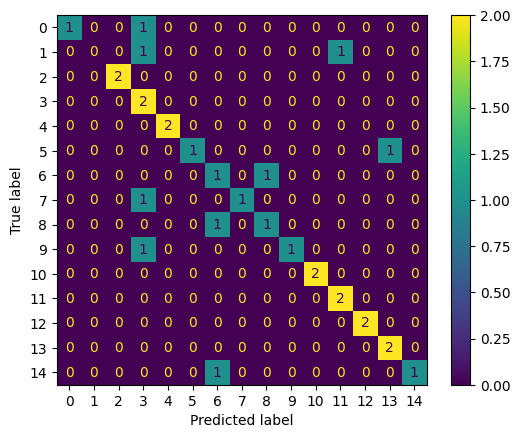

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
cm.shape

(15, 15)

### Other bunch of pre trained models:
https://dlib.net/files/

dlib is an open-source machine learning toolkit written in C++ with Python bindings.
It’s widely used for:

Face detection

Face landmark detection

Face recognition

Object detection

Image processing

Machine learning (SVM, kNN, regression, clustering, etc.)

## Detecting Facial points:
* Using 68 points face detector.
* Using 5 poins Face detector.

In [ ]:
import dlib

In [ ]:
face_detector = dlib.get_frontal_face_detector()
# Using 5 points  face detector.
#points_detector = dlib.shape_predictor('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/09_Face_detection/shape_predictor_5_face_landmarks.dat')
# Using 68 points face detector.
points_detector = dlib.shape_predictor('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/09_Face_detection/shape_predictor_68_face_landmarks.dat/shape_predictor_68_face_landmarks.dat')

In [ ]:
image = cv2.imread('/content/drive/MyDrive/MCV_Continuatin_inGoogle_Colab/08_Object_Detection/people2.jpg')

In [ ]:
#image

In [ ]:
face_detection = face_detector(image,1)

In [ ]:
face_detection

rectangles[[(429, 38) (465, 74)], [(665, 90) (701, 126)], [(717, 103) (760, 146)], [(909, 70) (952, 113)], [(828, 98) (871, 142)], [(605, 70) (641, 106)], [(777, 62) (813, 98)], [(485, 78) (521, 114)], [(386, 60) (429, 103)], [(170, 41) (213, 84)], [(93, 89) (136, 132)], [(237, 50) (280, 94)], [(323, 50) (367, 94)], [(544, 65) (588, 108)]]

In [ ]:
len(face_detection)

14

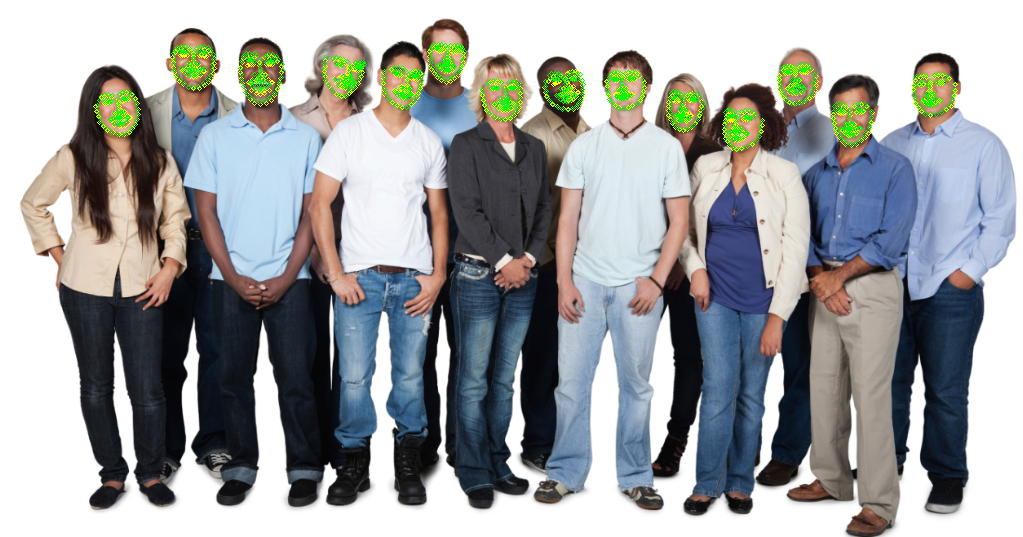

In [ ]:
for face in face_detection:
  points= points_detector(image, face)
  #print(points.parts())
  for p in points.parts():
    cv2.circle(image, (p.x,p.y), 2, (0,255,0), 1)
cv2_imshow(image)

In [ ]:
face_detection # This gives rectangle.

rectangles[[(429, 38) (465, 74)], [(665, 90) (701, 126)], [(717, 103) (760, 146)], [(909, 70) (952, 113)], [(828, 98) (871, 142)], [(605, 70) (641, 106)], [(777, 62) (813, 98)], [(485, 78) (521, 114)], [(386, 60) (429, 103)], [(170, 41) (213, 84)], [(93, 89) (136, 132)], [(237, 50) (280, 94)], [(323, 50) (367, 94)], [(544, 65) (588, 108)]]

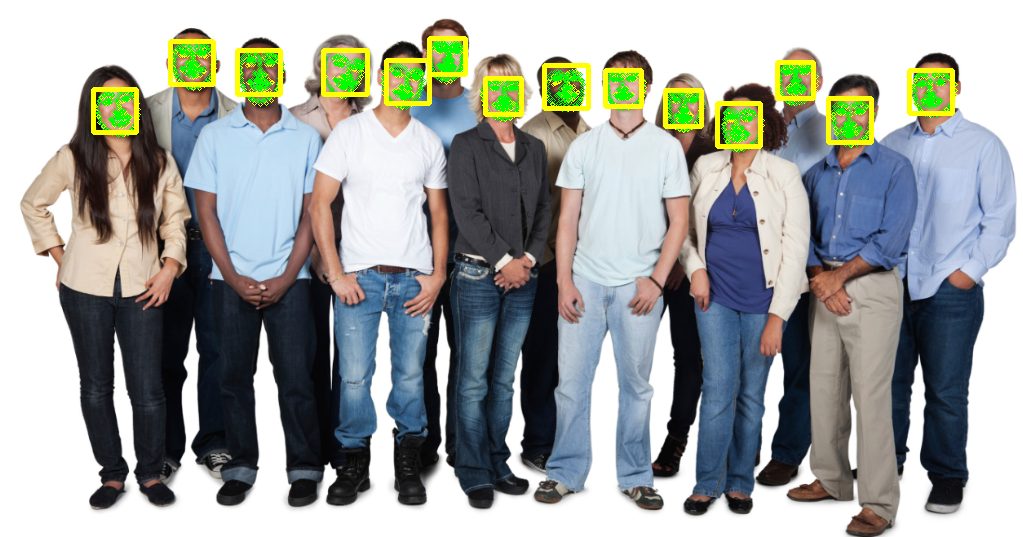

In [ ]:
for face in face_detection:
  points= points_detector(image, face)
  #print(points.parts())
  for p in points.parts():
    cv2.circle(image, (p.x,p.y), 2, (0,255,0), 1)
  l,t,r,b = face.left(), face.top(), face.right(), face.bottom()
  cv2.rectangle(image, (l,t),(r,b),(0,255,255),3)


cv2_imshow(image)